# Importo le librerie necessarie


In [18]:
from re import match

from dask.optimization import inline
import math
from IPython.display  import display
from jupyter_events.cli import console
from pymongo import MongoClient
import matplotlib.pyplot as plt
import pandas as pd
import pprint

# Attivazione della connessione con MongoDB

In [19]:
# Chiamo il client
client = MongoClient("mongodb://localhost:27017/")

#Acquisisco il DB
db = client["KeybladeDB"]

#Prendo in esempio il dataset videogames_2016
videogames_2016 = db["videogames_2016"]
videogames_2024 = db["videogames_2024"]

# Caricamento dei dati dal dataset MongoDB

In [20]:
# Carica i dati dal database
df_2016 = pd.DataFrame(list(videogames_2016.find()))
df_2024 = pd.DataFrame(list(videogames_2024.find()))

# Controlla i nomi delle colonne
print(df_2016.columns)
print(df_2024.columns)

Index(['_id', 'Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher',
       'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales',
       'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Developer',
       'Rating', 'last_update'],
      dtype='object')
Index(['_id', 'title', 'console', 'genre', 'publisher', 'developer',
       'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales',
       'other_sales', 'release_date', 'last_update'],
      dtype='object')


# Grafico che mette a confronto le vendite globali del dataset del 2016 con quelle del dataset del 2024

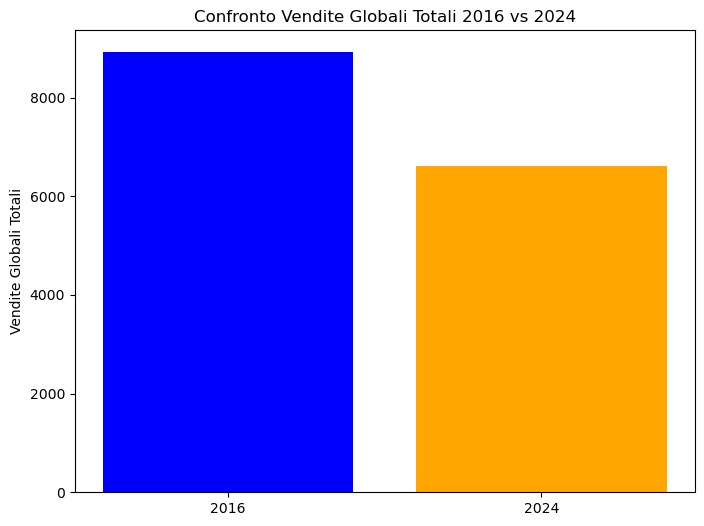

In [21]:
# Calcolo vendite totali per ciascun anno
total_sales_2016 = df_2016['Global_Sales'].sum()
total_sales_2024 = df_2024['total_sales'].sum()

# Dati e etichette
years = ['2016', '2024']
total_sales = [total_sales_2016, total_sales_2024]

# Grafico
plt.figure(figsize=(8,6))
plt.bar(years, total_sales, color=['blue', 'orange'])
plt.ylabel('Vendite Globali Totali')
plt.title('Confronto Vendite Globali Totali 2016 vs 2024')
plt.show()


# Query per la visualizzazione di giochi per rating (2016)

In [22]:
#Visualizzo i rating distinti presenti nel dataset videogames_2016
ratings=videogames_2016.distinct("Rating")

#creo un dizionario per la lista dei nomi per ciascun rating
rating_list={}

# Per ogni rating eseguo aggregazione
for rating in ratings:
    pipeline = [
        {"$match": {"Rating": rating}},
        {"$project": {"Name": 1, "Platform": 1, "_id": 0}}
    ]
    games = videogames_2016.aggregate(pipeline)
    games_df = pd.DataFrame(list(games))
    rating_list[rating] = games_df

# Visualizzazione dei risultati
for rating, games_df in rating_list.items():
    print(f"Giochi con rating {rating}:")
    display(games_df)
    print("\n")


Giochi con rating AO:


,Name,Platform
0,Grand Theft Auto: San Andreas,XB




Giochi con rating E:


,Name,Platform
0,Wii Sports,Wii
1,Mario Kart Wii,Wii
2,Wii Sports Resort,Wii
3,New Super Mario Bros.,DS
4,Wii Play,Wii
...,...,...
3989,Worms 2,PC
3990,Planet Monsters,GBA
3991,Bust-A-Move 3000,GC
3992,Mega Brain Boost,DS




Giochi con rating E10+:


...

,Name,Platform
0,Grand Theft Auto V,PS3
1,Grand Theft Auto: San Andreas,PS2
2,Grand Theft Auto V,X360
3,Grand Theft Auto: Vice City,PS2
4,Call of Duty: Modern Warfare 3,X360
...,...,...
1558,Xblaze: Lost Memories,PSV
1559,Metal Gear Solid HD Edition,X360
1560,Metal Gear Solid V: The Definitive Experience,XOne
1561,Mortal Kombat: Deadly Alliance,GBA




Giochi con rating RP:


,Name,Platform
0,Super Mario Bros.,NES
1,Pokemon Red/Pokemon Blue,GB
2,Tetris,GB
3,Duck Hunt,NES
4,Nintendogs,DS
...,...,...
6765,Samurai Warriors: Sanada Maru,PS3
6766,LMA Manager 2007,X360
6767,Haitaka no Psychedelica,PSV
6768,Spirits & Spells,GBA




Giochi con rating T:


,Name,Platform
0,Super Smash Bros. Brawl,Wii
1,Final Fantasy VII,PS
2,Gran Turismo 2,PS
3,Final Fantasy X,PS2
4,The Sims 3,PC
...,...,...
2956,Super Robot Taisen: Original Generation,GBA
2957,End of Nations,PC
2958,Outdoors Unleashed: Africa 3D,3DS
2959,Breach,PC


# Query per la visualizzazione delle vendite totali dei giochi in base al Developer (Video giochi 2016)

In [23]:
# Recupero dei developer distinti
developers = videogames_2016.distinct("Developer")

# Lista per raccogliere i risultati
rows = []

# Ciclo sui developer
for developer in developers:
    if developer == "Unknown":
        # Visualizza giochi singoli per Unknown
        pipeline = [
            {"$match": {"Developer": "Unknown"}},
            {"$project": {"Developer": 1,"Global_Sales": 1, "_id": 0}}
        ]
        result = list(videogames_2016.aggregate(pipeline))
        rows.extend(result)
    else:
        # Somma le vendite per gli altri developer
        pipeline = [
            {"$match": {"Developer": developer}},
            {"$group": {
                "_id": "$Developer",
                "Global_Sales": {"$sum": "$Global_Sales"}
            }}
        ]
        result = list(videogames_2016.aggregate(pipeline))
        if result:
            rows.append({"Developer": developer, "Global_Sales": result[0]["Global_Sales"]})
        else:
            rows.append({"Developer": developer,"Global_Sales": 0})

# Creazione del DataFrame
sales_df = pd.DataFrame(rows)
# Ordinamento per Global_Sales
sales_df = sales_df.sort_values(by="Global_Sales", ascending=False)

# Visualizzazione
display(sales_df)

,Developer,Global_Sales
1020,Nintendo,531.71
449,EA Sports,175.38
431,EA Canada,142.32
1539,Ubisoft,132.54
1220,Rockstar North,119.47
...,...,...
7962,Unknown,0.01
7961,Unknown,0.01
7960,Unknown,0.01
7959,Unknown,0.01


# Query per la visualizzazione delle vendite totali dei giochi in base al Developer (Video giochi 2024)

In [24]:
# Recupero dei developer distinti
developers = videogames_2024.distinct("developer")

# Lista per raccogliere i risultati
rows = []

# Ciclo sui developer
for developer in developers:
    if developer == "Unknown":
        # Visualizza giochi singoli per Unknown
        pipeline = [
            {"$match": {"developer": "Unknown"}},
            {"$project": {"developer": 1, "total_sales": 1, "_id": 0}}
        ]
        result = list(videogames_2024.aggregate(pipeline))
        rows.extend(result)
    else:
        # Somma le vendite per gli altri developer
        pipeline = [
            {"$match": {"developer": developer}},
            {"$group": {
                "_id": "$developer",
                "total_sales": {"$sum": "$total_sales"}
            }}
        ]
        result = list(videogames_2024.aggregate(pipeline))
        if result:
            rows.append({"developer": developer, "total_sales": result[0]["total_sales"]})
        else:
            rows.append({"developer": developer, "total_sales": 0})

# Creazione del DataFrame
sales_df = pd.DataFrame(rows)
# Ordinamento per total_sales
sales_df = sales_df.sort_values(by="total_sales", ascending=False)

# Visualizzazione
display(sales_df)


,developer,total_sales
2251,EA Canada,275.56
2269,EA Tiburon,178.33
7945,Ubisoft Montreal,172.96
7828,Treyarch,150.19
7816,Traveller's Tales,149.55
...,...,...
5231,Nibris,0.00
5233,Nicely Crafted,0.00
5234,Nichibutsu,0.00
5235,Nick Metnik,0.00


# Query che permette di visualizzare per ogni singolo videogioco, il numero totale di copie vendute in ogni continente (Dataset del 2016)

In [25]:
# Pipeline: visualizza tutti i giochi con dettagli di vendita
pipeline = [
    {"$project": {
        "_id": 0,
        "Developer": 1,
        "Global_Sales": 1,
        "NA_Sales": 1,
        "EU_Sales": 1,
        "JP_Sales": 1,
        "Other_Sales": 1
    }},
    {"$sort": {"Global_Sales": -1}}
]#Inserendo il -1 nell'operazione di sort, i risultati vengono ordinati in ordine decrescente in base alle vendite globali

# Esecuzione della pipeline
result = list(videogames_2016.aggregate(pipeline))
# Conversione in DataFrame
sales_df = pd.DataFrame(result)

# Visualizzazione
display(sales_df)


,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Developer
0,41.36,28.96,3.77,8.45,82.53,Nintendo
1,29.08,3.58,6.81,0.77,40.24,Unknown
2,15.68,12.76,3.79,3.29,35.52,Nintendo
3,15.61,10.93,3.28,2.95,32.77,Nintendo
4,11.27,8.89,10.22,1.00,31.37,Unknown
...,...,...,...,...,...,...
16712,0.00,0.00,0.01,0.00,0.01,Unknown
16713,0.00,0.01,0.00,0.00,0.01,Unknown
16714,0.00,0.00,0.01,0.00,0.01,Unknown
16715,0.01,0.00,0.00,0.00,0.01,Unknown


# Query che permette di visualizzare per ogni singolo videogioco, il numero totale di copie vendute in ogni continente (Dataset del 2024)

In [26]:
# Pipeline: visualizza tutti i giochi con dettagli di vendita
pipeline = [
    {"$project": {
        "_id": 0,
        "developer": 1,
        "total_sales": 1,
        "na_sales": 1,
        "pal_sales": 1,
        "jp_sales": 1,
        "other_sales": 1
    }},
    {"$sort": {"total_sales": -1}}
]#Inserendo il -1 nell'operazione di sort, i risultati vengono ordinati in ordine decrescente in base alle vendite globali

# Esecuzione della pipeline
result = list(videogames_2024.aggregate(pipeline))
# Conversione in DataFrame
sales_df = pd.DataFrame(result)

# Visualizzazione
display(sales_df)

,developer,total_sales,na_sales,jp_sales,pal_sales,other_sales
0,Rockstar North,20.32,6.37,0.99,9.85,3.12
1,Rockstar North,19.39,6.06,0.60,9.71,3.02
2,Rockstar North,16.15,8.41,0.47,5.49,1.78
3,Rockstar North,15.86,9.06,0.06,5.33,1.42
4,Treyarch,15.09,6.18,0.41,6.05,2.44
...,...,...,...,...,...,...
64011,Arc System Works,0.00,0.00,0.00,0.00,0.00
64012,Nippon Ichi Software,0.00,0.00,0.00,0.00,0.00
64013,Nippon Ichi Software,0.00,0.00,0.00,0.00,0.00
64014,Otomate,0.00,0.00,0.00,0.00,0.00


# Query che permette di visualizzare il Publisher che ha ottenuto un Critic_Score maggiore per il dataset del 2016

In [27]:
pipeline = [
    # 1. Filtra i giochi con Critic_Score e Publisher validi
    {
        "$match": {
            "Critic_Score": {"$ne": None},
            "Publisher": {"$ne": None}
        }
    },
    # 2. Aggiunge un campo normalizzato (Critic_Score / 10)
    {
        "$addFields": {
            "Critic_Score_Norm": { "$divide": ["$Critic_Score", 10] }
        }
    },
    # 3. Raggruppa per Publisher e calcola la media del punteggio normalizzato
    {
        "$group": {
            "_id": "$Publisher",
            "avg_critic_score": { "$avg": "$Critic_Score_Norm" }
        }
    },
    # 4. Ordina per media discendente
    {
        "$sort": { "avg_critic_score": -1 }
    },
    # 5. Limita ai primi 1
    {
        "$limit": 1
    },
    # 6. Proietta un output più leggibile
    {
        "$project": {
            "_id": 0,
            "Publisher": "$_id",
            "avg_critic_score": 1
        }
    }
]

result = list(db.videogames_2016.aggregate(pipeline))

if result:
    print("Publisher con la media più alta di Critic_Score normalizzato (scala 10):\n")
    for r in result:
        print(f"Publisher: {r['Publisher']}, Media Critic_Score: {r['avg_critic_score']:.2f}")
else:
    print("Nessun dato valido trovato nel dataset 2016.")


Publisher con la media più alta di Critic_Score normalizzato (scala 10):

Publisher: Valve, Media Critic_Score: 9.50


# Query che permette di visualizzare il Publisher che ha ottenuto un Critic_Score maggiore per il dataset del 2024

In [28]:
pipeline = [
    # 1. Filtra i documenti con critic_score e publisher non nulli
    {
        "$match": {
            "critic_score": {"$ne": None},
            "publisher": {"$ne": None}
        }
    },
    # 2. Raggruppa per publisher e calcola la media dei critic_score
    {
        "$group": {
            "_id": "$publisher",
            "avg_critic_score": { "$avg": "$critic_score" }
        }
    },
    # 3. Ordina per media discendente
    {
        "$sort": { "avg_critic_score": -1 }
    },
    # 4. Limita ai primi 1 (top publisher)
    {
        "$limit": 1
    },
    # 5. Proietta un output pulito
    {
        "$project": {
            "_id": 0,
            "publisher": "$_id",
            "avg_critic_score": 1
        }
    }
]

result = list(db.videogames_2024.aggregate(pipeline))

if result:
    print("Publisher con la media più alta di critic_score:\n")
    for r in result:
        print(f"Publisher: {r['publisher']}, Media critic_score: {r['avg_critic_score']:.2f}")
else:
    print("Nessun dato valido trovato nel dataset 2024.")

Publisher con la media più alta di critic_score:

Publisher: Bimboosoft, Media critic_score: 9.40


# Query che prende in input un Developer e restituisce la media del Critic_Score effettuata dai critici per il dataset del 2016

In [29]:
pipeline = [
    # 1. Filtra documenti con Critic_Score e Developer non nulli
    {
        "$match": {
            "Critic_Score": {"$ne": None},
            "Developer": {"$ne": None}
        }
    },
    # 2. Proietta la normalizzazione del punteggio (divisione per 10)
    {
        "$addFields": {
            "Critic_Score_norm": { "$divide": ["$Critic_Score", 10] }
        }
    },
    # 3. Raggruppa per Developer e calcola la media normalizzata
    {
        "$group": {
            "_id": "$Developer",
            "avg_Critic_Score": { "$avg": "$Critic_Score_norm" }
        }
    },
    # 4. Ordina per media discendente
    {
        "$sort": { "avg_Critic_Score": -1 }
    },
    # 5. Proietta output pulito
    {
        "$project": {
            "_id": 0,
            "Developer": "$_id",
            "avg_Critic_Score": 1
        }
    }
]

result = list(db.videogames_2016.aggregate(pipeline))

if result:
    print("Media normalizzata Critic_Score per Developer (ordinato dal più alto):\n")
    for r in result:
        print(f"Developer: {r['Developer']}, Media Critic_Score: {r['avg_Critic_Score']:.2f}")
else:
    print("Nessun dato valido trovato nel dataset 2016.")


Media normalizzata Critic_Score per Developer (ordinato dal più alto):

Developer: Irrational Games, 2K Marin, Media Critic_Score: 9.60
Developer: Digital Extremes, 2K Marin, Media Critic_Score: 9.40
Developer: Bungie Software, Media Critic_Score: 9.37
Developer: DMA Design, Rockstar North, Media Critic_Score: 9.30
Developer: Rockstar North, Media Critic_Score: 9.29
Developer: ThatGameCompany, Media Critic_Score: 9.20
Developer: Irrational Games, Media Critic_Score: 9.15
Developer: Valve Software, Media Critic_Score: 9.14
Developer: Psygnosis, Media Critic_Score: 9.10
Developer: Headgate, Media Critic_Score: 9.10
Developer: SCE/WWS, Media Molecule, Media Critic_Score: 9.10
Developer: Bethesda Game Studios, Media Critic_Score: 9.06
Developer: 2D Boy, Media Critic_Score: 9.00
Developer: Number None Inc., Knockout Games, Media Critic_Score: 9.00
Developer: Lead Pursuit, Media Critic_Score: 9.00
Developer: Retro Studios, Media Critic_Score: 9.00
Developer: EA Sports Big, Media Critic_Score

# Query che prende in input un Developer e restituisce la media del Critic_Score effettuata dai critici per il dataset del 2024

In [30]:
pipeline = [
    # 1. Filtra documenti con critic_score e developer non nulli
    {
        "$match": {
            "critic_score": {"$ne": None},
            "developer": {"$ne": None}
        }
    },
    # 2. Raggruppa per developer e calcola la media di critic_score
    {
        "$group": {
            "_id": "$developer",
            "avg_critic_score": {"$avg": "$critic_score"}
        }
    },
    # 3. Ordina per media discendente
    {
        "$sort": {"avg_critic_score": -1}
    },
    # 4. Proietta in output pulito
    {
        "$project": {
            "_id": 0,
            "developer": "$_id",
            "avg_critic_score": 1
        }
    }
]

result = list(db.videogames_2024.aggregate(pipeline))

if result:
    print("Media critic_score per developer (ordinato dal più alto):\n")
    for r in result:
        print(f"Developer: {r['developer']}, Media critic_score: {r['avg_critic_score']:.2f}")
else:
    print("Nessun dato valido trovato nel dataset 2024.")


Media critic_score per developer (ordinato dal più alto):

Developer: VGChartz, Media critic_score: 10.00
Developer: Starfire Studios, Media critic_score: 10.00
Developer: Flagship Co., Ltd. / Nintendo EAD, Media critic_score: 9.60
Developer: 2K Australia / 2K Boston, Media critic_score: 9.60
Developer: Raster, Media critic_score: 9.30
Developer: 2K Boston / 2K Australia / 2K Marin, Media critic_score: 9.30
Developer: BioWare / Demiurge Studios, Media critic_score: 9.10
Developer: KCEJ / Kojima Productions, Media critic_score: 9.00
Developer: Ready at Dawn Studios, Media critic_score: 9.00
Developer: Villa Gorilla, Media critic_score: 9.00
Developer: Peter Stock, Media critic_score: 9.00
Developer: Press Start Inc./ High Score Productions, Media critic_score: 9.00
Developer: Team ICO, Media critic_score: 8.95
Developer: Criterion, Media critic_score: 8.90
Developer: Irrational Games / Looking Glass Studios, Media critic_score: 8.90
Developer: Nayantara Studios, Media critic_score: 8.80

# Query che prende in input un Publisher e restituisce la media del Critic_Score effettuata dai critici per il dataset del 2016

In [31]:
pipeline = [
    # 1. Filtra documenti con Critic_Score e Publisher non nulli
    {
        "$match": {
            "Critic_Score": {"$ne": None},
            "Publisher": {"$ne": None}
        }
    },
    # 2. Aggiungi campo con Critic_Score normalizzato (diviso 10)
    {
        "$addFields": {
            "Critic_Score_norm": { "$divide": ["$Critic_Score", 10] }
        }
    },
    # 3. Raggruppa per Publisher e calcola media Critic_Score normalizzato
    {
        "$group": {
            "_id": "$Publisher",
            "avg_Critic_Score": { "$avg": "$Critic_Score_norm" }
        }
    },
    # 4. Ordina per media discendente
    {
        "$sort": { "avg_Critic_Score": -1 }
    },
    # 5. Proietta i campi in output pulito
    {
        "$project": {
            "_id": 0,
            "Publisher": "$_id",
            "avg_Critic_Score": 1
        }
    }
]

result = list(db.videogames_2016.aggregate(pipeline))

if result:
    print("Media Critic_Score normalizzato per Publisher (ordinato dal più alto):\n")
    for r in result:
        print(f"Publisher: {r['Publisher']}, Media Critic_Score: {r['avg_Critic_Score']:.2f}")
else:
    print("Nessun dato valido trovato nel dataset 2016.")


Media Critic_Score normalizzato per Publisher (ordinato dal più alto):

Publisher: Valve, Media Critic_Score: 9.50
Publisher: Valve Software, Media Critic_Score: 9.30
Publisher: 2D Boy, Media Critic_Score: 9.00
Publisher: Graphsim Entertainment, Media Critic_Score: 9.00
Publisher: Number None, Media Critic_Score: 9.00
Publisher: Havas Interactive, Media Critic_Score: 8.80
Publisher: Activision Blizzard, Media Critic_Score: 8.70
Publisher: Yacht Club Games, Media Critic_Score: 8.62
Publisher: GOA, Media Critic_Score: 8.60
Publisher: Codemasters Online, Media Critic_Score: 8.50
Publisher: id Software, Media Critic_Score: 8.50
Publisher: Slightly Mad Studios, Media Critic_Score: 8.23
Publisher: inXile Entertainment, Media Critic_Score: 8.10
Publisher: RedOctane, Media Critic_Score: 8.10
Publisher: Square Enix , Media Critic_Score: 8.05
Publisher: Wargaming.net, Media Critic_Score: 8.00
Publisher: Square EA, Media Critic_Score: 8.00
Publisher: Team17 Software, Media Critic_Score: 7.90
Publ

# Query che prende in input un Publisher e restituisce la media del Critic_Score effettuata dai critici per il dataset del 2024

In [32]:
pipeline = [
    # 1. Filtra documenti con critic_score e publisher non nulli
    {
        "$match": {
            "critic_score": {"$ne": None},
            "publisher": {"$ne": None}
        }
    },
    # 2. Raggruppa per publisher e calcola media di critic_score
    {
        "$group": {
            "_id": "$publisher",
            "avg_critic_score": {"$avg": "$critic_score"}
        }
    },
    # 3. Ordina per media decrescente
    {
        "$sort": {"avg_critic_score": -1}
    },
    # 4. Proietta campi in output pulito
    {
        "$project": {
            "_id": 0,
            "publisher": "$_id",
            "avg_critic_score": 1
        }
    }
]

result = list(db.videogames_2024.aggregate(pipeline))

if result:
    print("Media critic_score per Publisher (ordinato dal più alto):\n")
    for r in result:
        print(f"Publisher: {r['publisher']}, Media critic_score: {r['avg_critic_score']:.2f}")
else:
    print("Nessun dato valido trovato nel dataset 2024.")


Media critic_score per Publisher (ordinato dal più alto):

Publisher: Bimboosoft, Media critic_score: 9.40
Publisher: 2D Boy, Media critic_score: 9.20
Publisher: Psyonix Studios, Media critic_score: 9.20
Publisher: Number None, Media critic_score: 9.05
Publisher: Drool, Media critic_score: 9.00
Publisher: Mad Monkey Studio, Media critic_score: 9.00
Publisher: Villa Gorilla, Media critic_score: 9.00
Publisher: Nayantara Studios, Media critic_score: 8.80
Publisher: Sam Barlow, Media critic_score: 8.70
Publisher: QCF Design, Media critic_score: 8.50
Publisher: Skydance Interactive, Media critic_score: 8.50
Publisher: Pelfast, Media critic_score: 8.50
Publisher: Carpe Fulgur, Media critic_score: 8.30
Publisher: YuPlay, Media critic_score: 8.30
Publisher: Hidden Path Entertainment, Media critic_score: 8.25
Publisher: LDW, Media critic_score: 8.20
Publisher: Lionhead Studios, Media critic_score: 8.20
Publisher: Uber Entertainment, Media critic_score: 8.00
Publisher: Honeyslug, Media critic_s

# Query che prende in input un Developer e restituisce la media dello User_Score effettuata dagli utenti per il dataset del 2016

In [33]:
pipeline = [
    # 1. Filtra documenti con User_Score e Developer non nulli
    {
        "$match": {
            "User_Score": {"$ne": None},
            "Developer": {"$ne": None}
        }
    },
    # 2. Raggruppa per Developer e calcola media di User_Score
    {
        "$group": {
            "_id": "$Developer",
            "avg_User_Score": {"$avg": "$User_Score"}
        }
    },
    # 3. Ordina per media decrescente
    {
        "$sort": {"avg_User_Score": -1}
    },
    # 4. Proietta campi in output pulito
    {
        "$project": {
            "_id": 0,
            "Developer": "$_id",
            "avg_User_Score": 1
        }
    }
]

result = list(db.videogames_2016.aggregate(pipeline))

if result:
    print("Media User_Score per Developer (ordinato dal più alto):\n")
    for r in result:
        print(f"Developer: {r['Developer']}, Media User_Score: {r['avg_User_Score']:.2f}")
else:
    print("Nessun dato valido trovato nel dataset 2016.")


Media User_Score per Developer (ordinato dal più alto):

Developer: Infinite Dreams, Paragon 5, Media User_Score: 9.50
Developer: Inferno Games, Media User_Score: 9.50
Developer: Tecmo, Graphic Research, Media User_Score: 9.40
Developer: Pax Softonica, Media User_Score: 9.30
Developer: Telenet, Media User_Score: 9.30
Developer: Housemarque, Media User_Score: 9.20
Developer: Codo Games, Media User_Score: 9.10
Developer: Rockstar Vancouver, Media User_Score: 9.10
Developer: Quest, Media User_Score: 9.10
Developer: Victor Interactive Software, Media User_Score: 9.05
Developer: Swingin' Ape, Media User_Score: 9.00
Developer: Marvelous, Media User_Score: 9.00
Developer: Roxor Games, Media User_Score: 9.00
Developer: Flagship, Media User_Score: 9.00
Developer: GREZZO, Media User_Score: 9.00
Developer: Oddworld Inhabitants, Media User_Score: 8.97
Developer: Retro Studios, Media User_Score: 8.97
Developer: Blizzard North, Media User_Score: 8.95
Developer: Prolific, Media User_Score: 8.90
Devel

# Query che prende in input un Publisher e restituisce la media dello User_Score effettuata dagli utenti per il dataset del 2016

In [34]:
pipeline = [
    # 1. Filtra documenti con User_Score e Publisher non nulli
    {
        "$match": {
            "User_Score": {"$ne": None},
            "Publisher": {"$ne": None}
        }
    },
    # 2. Raggruppa per Publisher e calcola media di User_Score
    {
        "$group": {
            "_id": "$Publisher",
            "avg_User_Score": {"$avg": "$User_Score"}
        }
    },
    # 3. Ordina per media decrescente
    {
        "$sort": {"avg_User_Score": -1}
    },
    # 4. Proietta campi in output pulito
    {
        "$project": {
            "_id": 0,
            "Publisher": "$_id",
            "avg_User_Score": 1
        }
    }
]

result = list(db.videogames_2016.aggregate(pipeline))

if result:
    print("Media User_Score per Publisher (ordinato dal più alto):\n")
    for r in result:
        print(f"Publisher: {r['Publisher']}, Media User_Score: {r['avg_User_Score']:.2f}")
else:
    print("Nessun dato valido trovato nel dataset 2016.")


Media User_Score per Publisher (ordinato dal più alto):

Publisher: Sunflowers, Media User_Score: 9.10
Publisher: Havas Interactive, Media User_Score: 8.80
Publisher: Kool Kizz, Media User_Score: 8.80
Publisher: Max Five, Media User_Score: 8.70
Publisher: SCS Software, Media User_Score: 8.70
Publisher: Graphsim Entertainment, Media User_Score: 8.60
Publisher: Number None, Media User_Score: 8.60
Publisher: Valve Software, Media User_Score: 8.60
Publisher: Strategy First, Media User_Score: 8.60
Publisher: 2D Boy, Media User_Score: 8.50
Publisher: Pacific Century Cyber Works, Media User_Score: 8.40
Publisher: Valve, Media User_Score: 8.40
Publisher: Indie Games, Media User_Score: 8.40
Publisher: Funcom, Media User_Score: 8.30
Publisher: Phantagram, Media User_Score: 8.30
Publisher: Mamba Games, Media User_Score: 8.30
Publisher: NCSoft, Media User_Score: 8.28
Publisher: MC2 Entertainment, Media User_Score: 8.23
Publisher: id Software, Media User_Score: 8.20
Publisher: Codemasters Online, M

# Query che visualizza per ogni Publisher la media del Critic_Count, ovvero il numero di recensioni effettuate dai critici per il dataset del 2016

In [35]:
pipeline = [
    # 1. Filtra documenti con Critic_Count e Publisher non nulli
    {
        "$match": {
            "Critic_Count": {"$ne": None},
            "Publisher": {"$ne": None}
        }
    },
    # 2. Raggruppa per Publisher e calcola media di Critic_Count
    {
        "$group": {
            "_id": "$Publisher",
            "avg_Critic_Count": {"$avg": "$Critic_Count"}
        }
    },
    # 3. Ordina per media decrescente
    {
        "$sort": {"avg_Critic_Count": -1}
    },
    # 4. Proietta campi in output pulito
    {
        "$project": {
            "_id": 0,
            "Publisher": "$_id",
            "avg_Critic_Count": 1
        }
    }
]

result = list(db.videogames_2016.aggregate(pipeline))

if result:
    print("Media Critic_Count per Publisher (ordinato dal più alto):\n")
    for r in result:
        print(f"Publisher: {r['Publisher']}, Media Critic_Count: {r['avg_Critic_Count']:.2f}")
else:
    print("Nessun dato valido trovato nel dataset 2016.")


Media Critic_Count per Publisher (ordinato dal più alto):

Publisher: Hello Games, Media Critic_Count: 94.00
Publisher: inXile Entertainment, Media Critic_Count: 65.00
Publisher: Valve Software, Media Critic_Count: 57.67
Publisher: Valve, Media Critic_Count: 54.00
Publisher: GOA, Media Critic_Count: 54.00
Publisher: Sony Computer Entertainment Europe, Media Critic_Count: 52.47
Publisher: RedOctane, Media Critic_Count: 49.50
Publisher: Activision Blizzard, Media Critic_Count: 49.00
Publisher: Tripwire Interactive, Media Critic_Count: 44.00
Publisher: id Software, Media Critic_Count: 44.00
Publisher: NCSoft, Media Critic_Count: 40.50
Publisher: Crytek, Media Critic_Count: 40.00
Publisher: Microsoft Game Studios, Media Critic_Count: 39.06
Publisher: Daedalic Entertainment, Media Critic_Count: 39.00
Publisher: Harmonix Music Systems, Media Critic_Count: 39.00
Publisher: Bohemia Interactive, Media Critic_Count: 38.00
Publisher: Wargaming.net, Media Critic_Count: 38.00
Publisher: Square Enix

# Query che visualizza per ogni Developer la media del Critic_Count, ovvero il numero di recensioni effettuate dai critici per il dataset del 2016

In [36]:
pipeline = [
    # 1. Filtra documenti con Critic_Count e Developer validi
    {
        "$match": {
            "Critic_Count": {"$ne": None},
            "Developer": {"$ne": None}
        }
    },
    # 2. Raggruppa per Developer e calcola media di Critic_Count
    {
        "$group": {
            "_id": "$Developer",
            "avg_Critic_Count": { "$avg": "$Critic_Count" }
        }
    },
    # 3. Ordina per media decrescente
    {
        "$sort": { "avg_Critic_Count": -1 }
    },
    # 4. Rinomina campi per output pulito
    {
        "$project": {
            "_id": 0,
            "Developer": "$_id",
            "avg_Critic_Count": 1
        }
    }
]

result = list(db.videogames_2016.aggregate(pipeline))

if result:
    print("Media Critic_Count per Developer (ordinato dal più alto):\n")
    for r in result:
        print(f"Developer: {r['Developer']}, Media Critic_Count: {r['avg_Critic_Count']:.2f}")
else:
    print("Nessun dato valido trovato nel dataset 2016.")


Media Critic_Count per Developer (ordinato dal più alto):

Developer: The Coalition, Media Critic_Count: 96.00
Developer: Hello Games, Media Critic_Count: 94.00
Developer: Ruffian Games, Media Critic_Count: 91.00
Developer: Playground Games, Media Critic_Count: 87.50
Developer: Big Blue Box, Media Critic_Count: 87.00
Developer: Good-Feel, Media Critic_Count: 83.00
Developer: PLAYGROUND, Playground Games, Media Critic_Count: 83.00
Developer: Nintendo EAD Tokyo, Media Critic_Count: 82.50
Developer: 343 Industries, Media Critic_Count: 82.50
Developer: GREZZO, Media Critic_Count: 82.00
Developer: Team Bondi, Media Critic_Count: 80.50
Developer: Naughty Dog, Sony Bend, Media Critic_Count: 80.00
Developer: Turn 10, Media Critic_Count: 80.00
Developer: Media Molecule, Media Critic_Count: 79.33
Developer: ThatGameCompany, Media Critic_Count: 78.00
Developer: SCE/WWS, Media Molecule, Media Critic_Count: 76.50
Developer: Eurocom Entertainment Software, Visceral Games, Media Critic_Count: 76.00
D

# Giochi pubblicati in un determinato range temporale  (tramite publisher - 2024)

In [37]:
# Parametri di input
publisher_input = "Rockstar"
start_year = 2010
end_year = 2020

# Pipeline MongoDB
pipeline = [
    {
        "$match": {
            "publisher": {
                "$regex": publisher_input,
                "$options": "i"  # Match case-insensitive
            },
            "release_date": {
                "$gte": start_year,
                "$lte": end_year
            }
        }
    },
    {
        "$project": {
            "_id": 0,
            "title": 1,
            "console": 1,
            "genre": 1,
            "release_date": 1,
            "total_sales": 1
        }
    }
]

# Esecuzione della query
result = list(videogames_2024.aggregate(pipeline))

# Creazione del DataFrame
publisher_df = pd.DataFrame(result)
display(publisher_df)


,title,console,genre,total_sales,release_date
0,Grand Theft Auto V,PS3,Action,20.32,2013
1,Grand Theft Auto V,PS4,Action,19.39,2014
2,Grand Theft Auto V,X360,Action,15.86,2013
3,Red Dead Redemption 2,PS4,Action-Adventure,13.94,2018
4,Grand Theft Auto V,XOne,Action,8.72,2014
...,...,...,...,...,...
60,The Warriors,PS3,Misc,0.00,2013
61,Midnight Club: Los Angeles Complete Edition,PSN,Racing,0.00,2011
62,Max Payne 3,All,Shooter,0.00,2012
63,Max Payne 3,PC,Shooter,0.00,2012


# Query per la gestione delle vendite in base al genere (Per il dataset del 2024)

In [38]:
pipeline = [
        {"$match": {"genre": "Action"}},  # Match games with genre "Action"
        {"$project": {
            "_id": 0,
            "title": 1,
            "console": 1,
            "release_date": 1,
            "publisher": 1,
            "total_sales": 1
        }},
        {"$sort": {"total_sales": -1}} # Sort by Global_Sales in descending order
    ]

genre_df = pd.DataFrame(rows)
result = list(videogames_2024.aggregate(pipeline))
genre_df = pd.DataFrame(result)
display(genre_df)

,title,console,publisher,total_sales,release_date
0,Grand Theft Auto V,PS3,Rockstar Games,20.32,2013
1,Grand Theft Auto V,PS4,Rockstar Games,19.39,2014
2,Grand Theft Auto: Vice City,PS2,Rockstar Games,16.15,2002
3,Grand Theft Auto V,X360,Rockstar Games,15.86,2013
4,Grand Theft Auto III,PS2,Rockstar Games,13.10,2001
...,...,...,...,...,...
8552,Zoids Wild: Blast Unleashed,NS,Outright Games,0.00,2020
8553,Zoids Wild: King of Blast,NS,Takara Tomy,0.00,2019
8554,Zombeer,WiiU,Unknown,0.00,1970
8555,Zombie Brigade: No Brain No Gain,WiiU,Unknown,0.00,1970


# Query che visualiizza il margine di miglioramento dei punteggi dei giochi tra il 2016 e il 2024

In [39]:
pipeline = [
    # 1. Normalizza nome 2016
    {
        "$addFields": {
            "name_clean": {
                "$toLower": { "$trim": { "input": "$Name" } }
            }
        }
    },
    # 2. Filtro punteggi validi e diversi da zero
    {
        "$match": {
            "Critic_Score": { "$ne": None, "$ne": 0 }
        }
    },
    # 3. Join con 2024
    {
        "$lookup": {
            "from": "videogames_2024",
            "let": {
                "name_clean_2016": "$name_clean",
                "platform_2016": "$Platform"
            },
            "pipeline": [
                {
                    "$addFields": {
                        "name_clean": {
                            "$toLower": { "$trim": { "input": "$title" } }
                        }
                    }
                },
                {
                    "$match": {
                        "$expr": {
                            "$and": [
                                { "$ne": ["$critic_score", None] },
                                { "$ne": ["$critic_score", 0] },
                                { "$eq": ["$name_clean", "$$name_clean_2016"] },
                                { "$eq": ["$console", "$$platform_2016"] }
                            ]
                        }
                    }
                }
            ],
            "as": "matched_2024"
        }
    },
    # 4. Unwind match
    {
        "$unwind": "$matched_2024"
    },
    # 5. Normalizza punteggio 2024
    {
        "$addFields": {
            "critic_score_2024_norm": {
                "$multiply": [
                    { "$toDouble": "$matched_2024.critic_score" },
                    10
                ]
            }
        }
    },
    # 6. Calcola margine miglioramento
    {
        "$addFields": {
            "margine_miglioramento": {
                "$subtract": ["$Critic_Score", "$critic_score_2024_norm"]
            },
            "gioco": "$Name"
        }
    },
    # 7. Proiezione campi finali
    {
        "$project": {
            "_id": 0,
            "gioco": 1,
            "Platform": 1,
            "Critic_Score": 1,
            "critic_score_2024_norm": 1,
            "margine_miglioramento": 1
        }
    },
    # 8. Rimozione duplicati su gioco + piattaforma
    {
        "$group": {
            "_id": { "gioco": "$gioco", "Platform": "$Platform" },
            "doc": { "$first": "$$ROOT" }
        }
    },
    {
        "$replaceRoot": { "newRoot": "$doc" }
    },
    # 9. Ordinamento per margine
    {
        "$sort": { "margine_miglioramento": -1 }
    }
]

# Esegui la pipeline sulla collezione videogames_2016
risultati = list(db.videogames_2016.aggregate(pipeline))

# Stampa
if risultati:
    print(f"Totale risultati trovati: {len(risultati)}\n")
    for idx, r in enumerate(risultati, 1):
        print(f"--- Gioco {idx} ---")
        print(f"Nome: {r['gioco']}")
        print(f"Piattaforma: {r['Platform']}")
        print(f"Critic Score 2016: {r['Critic_Score']}")
        print(f"Critic Score 2024 (normalizzato): {r['critic_score_2024_norm']}")
        print(f"Margine miglioramento: {r['margine_miglioramento']}")
        print()
else:
    print("Nessun risultato trovato.")


Totale risultati trovati: 3462

--- Gioco 1 ---
Nome: 100 Classic Books
Piattaforma: DS
Critic Score 2016: 70.0
Critic Score 2024 (normalizzato): 40.0
Margine miglioramento: 30.0

--- Gioco 2 ---
Nome: Call of Duty: Modern Warfare 3
Piattaforma: Wii
Critic Score 2016: 70.0
Critic Score 2024 (normalizzato): 45.0
Margine miglioramento: 25.0

--- Gioco 3 ---
Nome: Fracture
Piattaforma: X360
Critic Score 2016: 63.0
Critic Score 2024 (normalizzato): 40.0
Margine miglioramento: 23.0

--- Gioco 4 ---
Nome: Iron Chef America: Supreme Cuisine
Piattaforma: Wii
Critic Score 2016: 42.0
Critic Score 2024 (normalizzato): 20.0
Margine miglioramento: 22.0

--- Gioco 5 ---
Nome: Kabuki Warriors
Piattaforma: XB
Critic Score 2016: 32.0
Critic Score 2024 (normalizzato): 10.0
Margine miglioramento: 22.0

--- Gioco 6 ---
Nome: Fracture
Piattaforma: PS3
Critic Score 2016: 62.0
Critic Score 2024 (normalizzato): 40.0
Margine miglioramento: 22.0

--- Gioco 7 ---
Nome: PowerUp Heroes
Piattaforma: X360
Critic Sco

# Query che visualizza in quale continente è stata effettuata la vendita maggiore e minore di un determinato gioco

In [40]:
game_title = "Grand Theft Auto V"

pipeline = [
    {
        "$match": {
            "title": {"$regex": f"^{game_title}$", "$options": "i"}
        }
    },
    {
        "$group": {
            "_id": "$title",
            "total_na_sales": {"$sum": "$na_sales"},
            "total_jp_sales": {"$sum": "$jp_sales"},
            "total_pal_sales": {"$sum": "$pal_sales"},
            "total_other_sales": {"$sum": "$other_sales"},
        }
    },
    {
        "$match": {  # Escludi giochi con tutte vendite a 0
            "$or": [
                {"total_na_sales": {"$gt": 0}},
                {"total_jp_sales": {"$gt": 0}},
                {"total_pal_sales": {"$gt": 0}},
                {"total_other_sales": {"$gt": 0}},
            ]
        }
    }
]

result = list(videogames_2024.aggregate(pipeline))

if result:
    data = result[0]
    title = data["_id"]

    sales_by_region = {
        "Nord America": data["total_na_sales"],
        "Giappone": data["total_jp_sales"],
        "Europa/PAL": data["total_pal_sales"],
        "Altri": data["total_other_sales"]
    }

    max_region = max(sales_by_region, key=sales_by_region.get)
    min_region = min(sales_by_region, key=sales_by_region.get)

    print(f"Titolo del gioco: {title}")
    print(f"Vendite maggiori: {max_region} ({sales_by_region[max_region]} milioni)")
    print(f"Vendite minori: {min_region} ({sales_by_region[min_region]} milioni)")
else:
    print(f"Nessun dato aggregato trovato per '{game_title}' o vendite totali nulle.")


Titolo del gioco: Grand Theft Auto V
Vendite maggiori: Europa/PAL (28.14 milioni)
Vendite minori: Giappone (1.66 milioni)


# Query che visualizza tutti i videogiochi che sono stati pubblicati da un determinato Publisher a partire dalla sua prima pubblicazione fino all'ultima

In [41]:
# Parametri
publisher_name = "Nintendo"
cutoff_year = 2024  # Stringa

# Pipeline
pipeline = [
    {
        "$match": {
            "publisher": {
                "$regex": f"^{publisher_name}$",  # match esatto
                "$options": "i"
            },
            "release_date": {
                "$lte": cutoff_year  # confronto su stringa
            }
        }
    },
    {
        "$project": {
            "_id": 0,
            "title": 1,
            "publisher": 1,
            "release_date": 1
        }
    },
    {
        "$sort": {
            "release_date": 1  # Ordina per data
        }
    }
]

# Esecuzione della query
results = list(videogames_2024.aggregate(pipeline))

# Stampa risultati
if results:
    print(f"Giochi pubblicati da {publisher_name} fino al 2024:\n")
    for game in results:
        print(f"  Nome del Gioco: {game.get('title', 'N/D')}")
        print(f"  Publisher: {game.get('publisher', 'N/D')}")
        print(f"  Data di rilascio: {game.get('release_date', 'N/D')}\n")
else:
    print(f"Nessun gioco trovato per {publisher_name} fino al 2024.")


Giochi pubblicati da Nintendo fino al 2024:

  Nome del Gioco: Kirby's Block Ball
  Publisher: Nintendo
  Data di rilascio: 1970

  Nome del Gioco: Nintengirls: College Girl & Friends
  Publisher: Nintendo
  Data di rilascio: 1975

  Nome del Gioco: Donkey Kong
  Publisher: Nintendo
  Data di rilascio: 1981

  Nome del Gioco: Popeye no Eigo Asobi
  Publisher: Nintendo
  Data di rilascio: 1983

  Nome del Gioco: Super Mario
  Publisher: Nintendo
  Data di rilascio: 1983

  Nome del Gioco: Mahjong
  Publisher: Nintendo
  Data di rilascio: 1983

  Nome del Gioco: 4 Nin uchi Mahjong
  Publisher: Nintendo
  Data di rilascio: 1984

  Nome del Gioco: F1 Race
  Publisher: Nintendo
  Data di rilascio: 1984

  Nome del Gioco: Mach Rider
  Publisher: Nintendo
  Data di rilascio: 1985

  Nome del Gioco: Hogan's Alley
  Publisher: Nintendo
  Data di rilascio: 1985

  Nome del Gioco: Donkey Kong Jr. Math
  Publisher: Nintendo
  Data di rilascio: 1985

  Nome del Gioco: Ice Climber
  Publisher: Ninte

# Query che permette di visualizzare il numero di vendite dei videogiochi maggiore in base al genere (la query fa una join prendendo i giochi che sono comuni in entrambi i dataset, effettua una media delle vendite e una volta effettuato il filtraggio per genere, la query restituisce la lista dei giochi che hanno venduto di più)

In [42]:
pipeline = [
    # 1. Proietta solo i campi necessari da 2016
    {
        "$project": {
            "_id": 0,
            "Name": 1,
            "Genre": 1,
            "Global_Sales_2016": "$Global_Sales"
        }
    },
    # 2. Lookup con videogames_2024 (con rename e filtro campi)
    {
        "$lookup": {
            "from": "videogames_2024",
            "localField": "Name",
            "foreignField": "title",
            "as": "sales_2024"
        }
    },
    # 3. Unwind dei risultati 2024 (potrebbe esserci più di un match)
    {
        "$unwind": "$sales_2024"
    },
    # 4. Calcola la media delle vendite (2016 e 2024)
    {
        "$addFields": {
            "Global_Sales_2024": "$sales_2024.total_sales",
            "Average_Sales": {
                "$avg": ["$Global_Sales_2016", "$sales_2024.total_sales"]
            },
            "Genre_2024": "$sales_2024.genre"
        }
    },
    # 5. Scegli il genere da 2016 (o fallback da 2024 se manca)
    {
        "$addFields": {
            "Genre": {
                "$ifNull": ["$Genre", "$Genre_2024"]
            }
        }
    },
    # 6. Proietta solo i campi finali
    {
        "$project": {
            "Name": 1,
            "Genre": 1,
            "Average_Sales": 1
        }
    },
    # 7. Raggruppa per genere e prendi il gioco con vendite medie massime
    {
        "$sort": { "Average_Sales": -1 }
    },
    {
        "$group": {
            "_id": "$Genre",
            "Name": { "$first": "$Name" },
            "Average_Sales": { "$first": "$Average_Sales" }
        }
    },
    # 8. Rinomina _id in Genre
    {
        "$project": {
            "_id": 0,
            "Genre": "$_id",
            "Name": 1,
            "Average_Sales": 1
        }
    },
    # 9. Ordina per vendite medie decrescente
    {
        "$sort": { "Average_Sales": -1 }
    }
]

result = list(db.videogames_2016.aggregate(pipeline))

if result:
    print(f"Migliori giochi per genere in base a vendite medie 2016-2024:\n")
    for i, r in enumerate(result, 1):
        print(f"{i}. Genere: {r['Genre']}")
        print(f"   Gioco: {r['Name']}")
        print(f"   Vendite medie: {r['Average_Sales']:.2f} milioni")
        print()
else:
    print("Nessun risultato trovato.")


Migliori giochi per genere in base a vendite medie 2016-2024:

1. Genere: Sports
   Gioco: Wii Sports
   Vendite medie: 41.27 milioni

2. Genere: Action
   Gioco: Grand Theft Auto V
   Vendite medie: 20.68 milioni

3. Genere: Platform
   Gioco: Super Mario Bros.
   Vendite medie: 20.12 milioni

4. Genere: Racing
   Gioco: Mario Kart Wii
   Vendite medie: 17.76 milioni

5. Genere: Puzzle
   Gioco: Tetris
   Vendite medie: 15.13 milioni

6. Genere: Shooter
   Gioco: Call of Duty: Black Ops 3
   Vendite medie: 14.86 milioni

7. Genere: Misc
   Gioco: Wii Play
   Vendite medie: 14.46 milioni

8. Genere: Simulation
   Gioco: Nintendogs
   Vendite medie: 12.34 milioni

9. Genere: Role-Playing
   Gioco: The Elder Scrolls V: Skyrim
   Vendite medie: 8.84 milioni

10. Genere: Fighting
   Gioco: Super Smash Bros. Brawl
   Vendite medie: 6.42 milioni

11. Genere: Adventure
   Gioco: Super Mario Land 2: 6 Golden Coins
   Vendite medie: 5.59 milioni

12. Genere: Strategy
   Gioco: Warzone 2100
   V

# Query che permette di visualizzare i videogiochi che sono stati pubblicati dal 2017 (compreso) al 2024 con la corrispondente data dell'ultimo aggiornamento ricevuto

In [43]:
print("\n--- Tutti i Giochi dal 2017 nel dataset videogames_2024 (con Ultimo Aggiornamento) ---")

pipeline_all_2024_games_from_2017 = [
    # Estrai l'anno dalla data di rilascio
    {
        "$addFields": {
            "release_year": {
                "$toInt": {
                    "$substr": [{"$ifNull": ["$release_date", "0"]}, 0, 4]
                }
            }
        }
    },
    # Filtra solo i giochi rilasciati dal 2017 in poi
    {
        "$match": {
            "release_year": {"$gte": 2017}
        }
    },
    # Proietta tutti i campi desiderati, incluso last_update
    {
        "$project": {
            "_id": 0,
            "title": 1,
            "console": 1,
            "developer": 1,
            "publisher": 1,
            "genre": 1,
            "na_sales": 1,
            "jp_sales": 1,
            "pal_sales": 1,
            "other_sales": 1,
            "total_sales": 1,
            "release_date": 1,
            "release_year": 1,
            "last_update": 1 # Include il campo last_update
        }
    },
    # Ordina per anno e poi per data di rilascio
    {
        "$sort": {
            "release_year": 1,
            "release_date": 1
        }
    }
]

# Esegui la pipeline per tutti i giochi dal 2017
all_2017_games_results = list(db.videogames_2024.aggregate(pipeline_all_2024_games_from_2017))

print(f"Totale giochi dal 2017 nel dataset 2024: {len(all_2017_games_results)}\n")

# Itera sui risultati e stampa le informazioni di ciascun gioco
for doc in all_2017_games_results:
    print(f"Titolo: {doc.get('title', 'N/A')}")
    print(f"Console: {doc.get('console', 'N/A')}")
    print(f"Sviluppatore: {doc.get('developer', 'N/A')}")
    print(f"Editore: {doc.get('publisher', 'N/A')}")
    print(f"Genere: {doc.get('genre', 'N/A')}")
    print(f"Anno di Rilascio: {doc.get('release_year', 'N/A')}")
    print(f"Vendite Totali: {doc.get('total_sales', 'N/A')}")
    print(f"Data di Rilascio: {doc.get('release_date', 'N/A')}")
    print(f"Ultimo Aggiornamento: {doc.get('last_update', 'N/D')}")
    print("-" * 50) # Separatore


--- Tutti i Giochi dal 2017 nel dataset videogames_2024 (con Ultimo Aggiornamento) ---
Totale giochi dal 2017 nel dataset 2024: 6558

Titolo: Anima - Gate of Memories
Console: PS4
Sviluppatore: Anima Games Studio
Editore: PQube
Genere: Action
Anno di Rilascio: 2017
Vendite Totali: 0.04
Data di Rilascio: 2017
Ultimo Aggiornamento: 2018
--------------------------------------------------
Titolo: Call of Duty: WWII
Console: PS4
Sviluppatore: Sledgehammer Games
Editore: Activision
Genere: Shooter
Anno di Rilascio: 2017
Vendite Totali: 13.4
Data di Rilascio: 2017
Ultimo Aggiornamento: 2017
--------------------------------------------------
Titolo: FIFA 18
Console: PS4
Sviluppatore: EA Vancouver
Editore: EA Sports
Genere: Sports
Anno di Rilascio: 2017
Vendite Totali: 11.8
Data di Rilascio: 2017
Ultimo Aggiornamento: 2018
--------------------------------------------------
Titolo: Super Comboman
Console: PC
Sviluppatore: Interabang Entertainment
Editore: Flashman Games
Genere: Action
Anno di R

# Query che verifica i videogiochi in comune presenti sia nel dataset del 2016 che nel dataset del 2024

In [52]:
# Assumiamo che 'db' sia l'oggetto database MongoDB già connesso e disponibile.

# Configurazione della pipeline per il dataset 2016
pipeline_2016 = [
    {
        '$project': {
            '_id': 0, # Esclude il campo _id
            'Name': '$Name',
            'Year_of_Release': '$Year_of_Release',
            'Genre': '$Genre',
            'Developer': '$Developer',
            'Publisher': '$Publisher',
            'Global_Sales': '$Global_Sales'
        }
    }
]
# Esegui la pipeline sulla collezione 2016 e recupera i dati come lista di dizionari
collection_2016 = db.videogames_2016
data_2016 = list(collection_2016.aggregate(pipeline_2016))


pipeline_2024 = [
    {
        '$project': {
            '_id': 0, # Esclude il campo _id
            'Name': '$title',
            'Year_of_Release': '$release_date',
            'Genre': '$genre',
            'Developer': '$developer',
            'Publisher': '$publisher',
            'Global_Sales': '$total_sales'
        }
    }
]
# Esegui la pipeline sulla collezione 2024 e recupera i dati come lista di dizionari
collection_2024 = db.videogames_2024
data_2024 = list(collection_2024.aggregate(pipeline_2024))

# Creiamo un set di tuple per il dataset 2016
set_2016 = set()
for game in data_2016:
    game_signature = (
        game.get('Name'),
        game.get('Year_of_Release'),
        game.get('Genre'),
        game.get('Developer'),
        game.get('Publisher'),
        game.get('Global_Sales')
    )
    set_2016.add(game_signature)

# Trova i giochi comuni iterando sul dataset 2024 e controllando la presenza nel set 2016.
common_games_list = []
for game_2024 in data_2024:
    game_signature_2024 = (
        game_2024.get('Name'),
        game_2024.get('Year_of_Release'),
        game_2024.get('Genre'),
        game_2024.get('Developer'),
        game_2024.get('Publisher'),
        game_2024.get('Global_Sales')
    )
    if game_signature_2024 in set_2016:
        common_games_list.append(game_2024) # Aggiungiamo il dizionario completo del gioco in comune


common_games_list.sort(key=lambda game: game.get('Year_of_Release', 0))

# --- Stampa dei Risultati ---
print("\n--- Giochi in comune tra il dataset 2016 e il dataset 2024 (con uguaglianza esatta) ---")
if common_games_list:
    # Stampa completa di ogni gioco in comune con tutte le sue informazioni, ora ordinati
    for game in common_games_list:
        print(f"Nome: {game.get('Name', 'N/D')}")
        print(f"Anno di Rilascio: {game.get('Year_of_Release', 'N/D')}")
        print(f"Genere: {game.get('Genre', 'N/D')}")
        print(f"Sviluppatore: {game.get('Developer', 'N/D')}")
        print(f"Editore: {game.get('Publisher', 'N/D')}")
        print(f"Vendite Globali: {game.get('Global_Sales', 'N/D')} milioni")
        print("-" * 30) # Linea separatrice per chiarezza

    # Stampa del numero totale di videogiochi in comune
    print(f"\nNumero totale di videogiochi in comune individuati: {len(common_games_list)}")
else:
    print("Nessun gioco trovato in comune con uguaglianza esatta dei campi specificati.")


--- Giochi in comune tra il dataset 2016 e il dataset 2024 (con uguaglianza esatta) ---
Nome: SD Gundam Gaiden: Knight Gundam Monogatari: Ooinaru Isan
Anno di Rilascio: 1991
Genere: Role-Playing
Sviluppatore: Unknown
Editore: Angel Studios
Vendite Globali: 0.29 milioni
------------------------------
Nome: Street Fighter II': Special Champion Edition (JP weekly sales)
Anno di Rilascio: 1993
Genere: Action
Sviluppatore: Unknown
Editore: Capcom
Vendite Globali: 0.07 milioni
------------------------------
Nome: Game no Kanzume Vol 2
Anno di Rilascio: 1994
Genere: Misc
Sviluppatore: Unknown
Editore: Sega
Vendite Globali: 0.05 milioni
------------------------------
Nome: Game no Kanzume Vol 1
Anno di Rilascio: 1994
Genere: Misc
Sviluppatore: Unknown
Editore: Sega
Vendite Globali: 0.05 milioni
------------------------------
Nome: Tokimeki Mahjong Paradise: Koi no Tenpai Beat
Anno di Rilascio: 1995
Genere: Misc
Sviluppatore: Unknown
Editore: Sonnet
Vendite Globali: 0.04 milioni
--------------